In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
import mpltern

In [2]:
#file names
f1 = 'momenta_all_events.txt'
f2 = 'momenta_delayed_events.txt'
f3 = 'momenta_direct_events.txt'

#file from which data will be extracted
file = f1

In [3]:
#The code in this location needs to be adapted depending on the data format

#Reading data
#the data does not contain a column header
#data is saved as:  pnx, pny, pnz,  p1x, p1y, p1z,  p2x, p2y, p2z,  p3x, p3y, p3z
#x:0, y:1, z:2 - (z is axis of polarization)
axis = 2
dataframe = read_csv(file, decimal = '.', dtype = float, sep=',', header=None, usecols=[3+axis,6+axis,9+axis])

#p1z --> x1, p2z --> y1, p3z --> z1
x1 = np.array(dataframe.values[:,0])
y1 = np.array(dataframe.values[:,1])
z1 = np.array(dataframe.values[:,2])

#making space in memory
del dataframe

In [4]:
#Add distance from point to side(axis yz, zx, xy)
def add_to(oktant,distance):
    oktant[0].append(distance[0])
    oktant[1].append(distance[1])
    oktant[2].append(distance[2])

#Add distance from point to side(axis yz, zx, xy)
#symmetrization – electrons are indistinguishable
def add_with_all_permutations(oktant,distance):
    oktant[0].append(distance[0])
    oktant[1].append(distance[1])
    oktant[2].append(distance[2])
    
    oktant[1].append(distance[0])
    oktant[2].append(distance[1])
    oktant[0].append(distance[2])
    
    oktant[2].append(distance[0])
    oktant[1].append(distance[1])
    oktant[0].append(distance[2])
    
    oktant[0].append(distance[0])
    oktant[2].append(distance[1])
    oktant[1].append(distance[2])
    
    oktant[1].append(distance[0])
    oktant[0].append(distance[1])
    oktant[2].append(distance[2])
    
    oktant[2].append(distance[0])
    oktant[0].append(distance[1])
    oktant[1].append(distance[2])

    
#Add distance from point to side(axis yz, zx, xy)
#symmetrization – electrons which are moving in the same direction are indistinguishable
#The first value in array 'side' have different direction
#different - is a number of different value in distance
def add_with_two_permutations(oktant, distance, different):
    oktant[0].append(distance[different])
    oktant[1].append(distance[(different+1)%3])
    oktant[2].append(distance[(different+2)%3])
    
    oktant[0].append(distance[different])
    oktant[1].append(distance[(different+2)%3])
    oktant[2].append(distance[(different+1)%3])
    

In [5]:
#preparing arrays

#temporary distance of [yz, zx, xy]
r = [0,0,0]

#Arrays representing faces of octahedron in following order:
#(+++),(-++),(--+),(+-+),(++-),(-+-),(---),(+--).
p0 = [[],[],[]]
p1 = [[],[],[]]
p2 = [[],[],[]]
p3 = [[],[],[]]
p4 = [[],[],[]]
p5 = [[],[],[]]
p6 = [[],[],[]]
p7 = [[],[],[]]

#array for the same momentum direction (+++ and ---)
main  = [[],[],[]]

#array where one momentum is in the opposite direction to the others
side  = [[],[],[]]

for i in range(len(x1)):
    
    #absolute value of the vector component
    dx=abs(x1[i])
    #absolute value of the vector component
    dy=abs(y1[i])
    #absolute value of the vector component
    dz=abs(z1[i])
    
    #plane equation
    t = dx+dy+dz
    
    #normalized distance from point (x,y,z) to yz line
    r[0] = dx/t
    #normalized distance from point (x,y,z) to zx line
    r[1] = dy/t
    #normalized distance from point (x,y,z) to xy line
    r[2] = dz/t
    
    #adding distances to each octant 
    if (x1[i]>=0 and y1[i]>=0 and z1[i]>=0):              
        add_to(p0,r)
        add_with_all_permutations(main,r)
        
    elif (x1[i]<0 and y1[i]>=0 and z1[i]>=0):        
        add_to(p1,r)
        add_with_two_permutations(side,r,0)

    elif (x1[i]<0 and y1[i]<0 and z1[i]>=0):
        add_to(p2,r)
        add_with_two_permutations(side,r,2)
        
    elif (x1[i]>=0 and y1[i]<0 and z1[i]>=0):
        add_to(p3,r)
        add_with_two_permutations(side,r,1)

    #########################################
    elif (x1[i]>=0 and y1[i]>=0 and z1[i]<0):
        add_to(p4,r)
        add_with_two_permutations(side,r,2)
        
    elif (x1[i]<0 and y1[i]>=0 and z1[i]<0):
        add_to(p5,r)
        add_with_two_permutations(side,r,1)

    elif (x1[i]<0 and y1[i]<0 and z1[i]<0):
        add_to(p6,r)
        add_with_all_permutations(main,r)

    elif (x1[i]>=0 and y1[i]<0 and z1[i]<0):
        add_to(p7,r)
        add_with_two_permutations(side,r,1)
    
    #normalization check
    #print(r[0],",",r[1],",",r[2]," : ",(r[0]+r[1]+r[2]))

#making space in memory
del x1
del y1
del z1

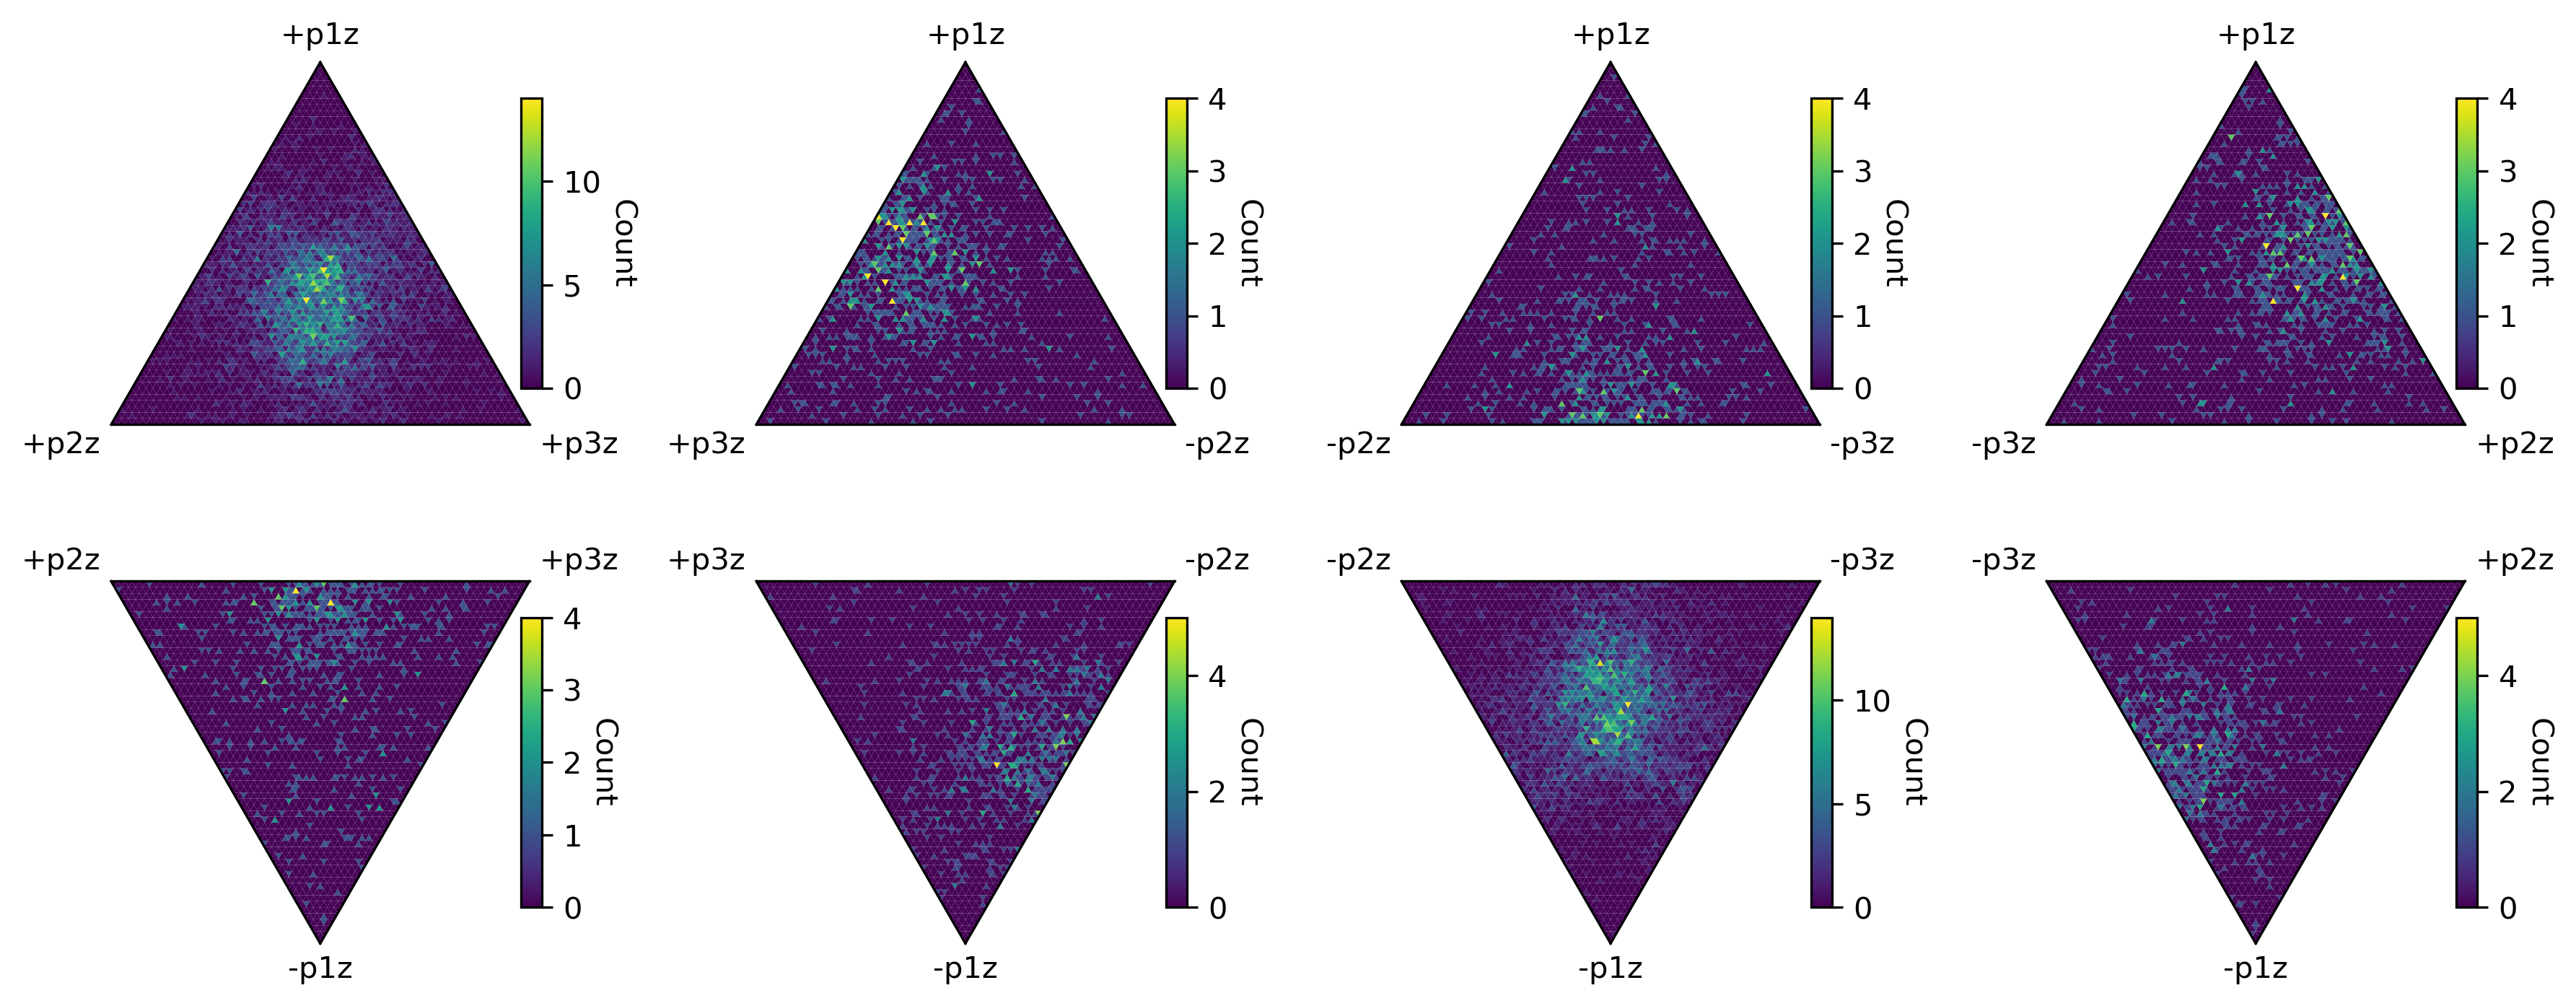

In [6]:
#Print the octahedron as a grid where the closest sides match up

#group all octants (to easier print)
p = [p0,p1,p2,p3,p4,p5,p6,p7]

#All labels (to easier print)
labelsP1 = ['+p1z','-p1z']
labelsP2 = ['+p2z','+p3z','-p2z','-p3z',  '+p3z','-p2z','-p3z','+p2z']
labelsP3 = ['+p3z','-p2z','-p3z','+p2z',  '+p2z','+p3z','-p2z','-p3z']

#Just single (they don't overlap)
#labelsP1 = ['+P1','-P1']
#labelsP2 = ['+P2','','','',  '','','','']
#labelsP3 = ['+P3','-P2','-P3','+P2',  '','','','']

#print helpers
rotation = 0 
down = 0

#the number of triangles into which the side of the triangle will be divided
grid = 60

#creating a figure
#increase "dpi" to improve detail quality
fig = plt.figure(figsize=(12,5), dpi=300)
fig.subplots_adjust(
    left=0.1,
    right=0.9,
    bottom=0.1,
    top=1,
    wspace=0.5,
    hspace=0.5,
)

for i,ps in enumerate(p):
    if(i==4):
        rotation = 180
        down = 1
        
    ax = fig.add_subplot(2, 4, i+1, projection='ternary', rotation=rotation)
    ax.set_tlabel(labelsP1[down])
    ax.set_llabel(labelsP2[i])
    ax.set_rlabel(labelsP3[i])
    
    #disable ticks on axis
    #comment 3 lines below to restore default settings
    ax.taxis.set_ticks([])
    ax.raxis.set_ticks([])
    ax.laxis.set_ticks([])
    
    #set the axis labels horizontally
    #comment 3 lines below to restore default settings
    ax.taxis.set_label_rotation_mode('horizontal')
    ax.laxis.set_label_rotation_mode('horizontal')
    ax.raxis.set_label_rotation_mode('horizontal')
    
    #Here we put the data of each oktant as (ps[0], ps[1], ps[2])
    #You can use line below (hexbin) instead of (tribin)
    #pc = ax.hexbin(ps[2], ps[(i+down)%2], ps[(i+1+down)%2], gridsize = grid, edgecolors=None)
    pc = ax.tribin(ps[2], ps[(i+down)%2], ps[(i+1+down)%2], gridsize = grid, edgecolors=None)
    
    cax = ax.inset_axes([0.98, 0.1, 0.05, 0.8])
    colorbar = fig.colorbar(pc, cax=cax)
    colorbar.set_label("Count", rotation=270, va="baseline")

    
plt.tight_layout()

# file[-9:-4] --> this fragment contains the power of the laser used to obtain the data
plt.savefig('oktants '+file[-9:-4]+'.png')
plt.show()

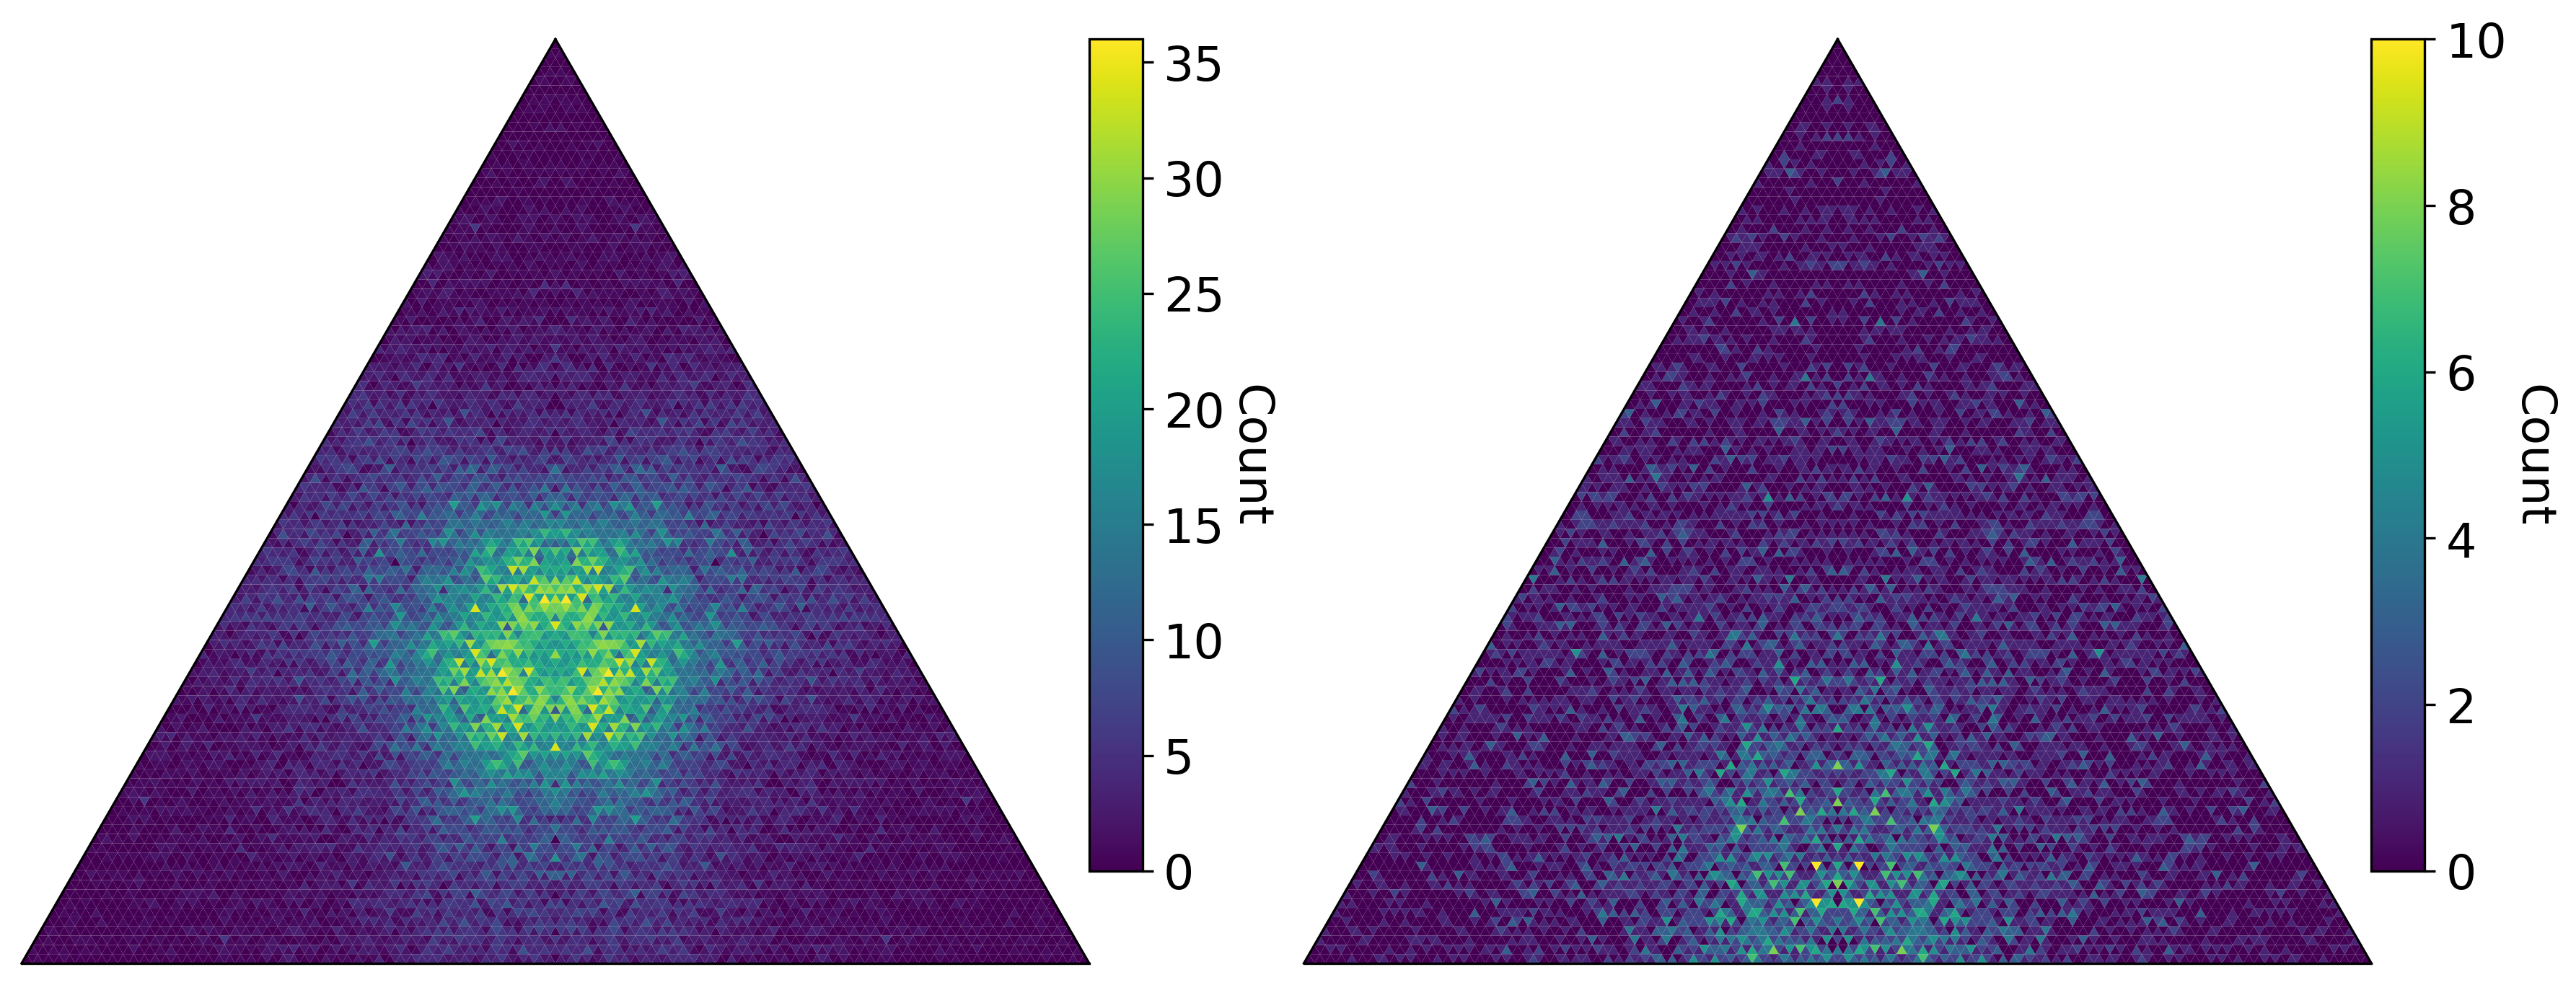

In [7]:
#draw two triangles (electrons with the same direction and electrons with the different directions)

#creating a figure
#increase "dpi" to improve detail quality
fig = plt.figure(figsize=(12,6), dpi=300)
fig.subplots_adjust(
    left=-0.1,
    right=0.9,
    bottom=0.1,
    top=0.9,
    wspace=0.5,
    hspace=0.,
)

rotation = 0
down = 0

#the number of triangles into which the side of the triangle will be divided
grid = 100

ax = fig.add_subplot(1, 2, 1, projection='ternary', rotation=rotation)
#ax.set_title('all electrons one direction')

#Printing the data (ps[0], ps[1], ps[2])
#pc = ax.hexbin(main[0], main[1], main[2], gridsize = grid, edgecolors=None)
pc = ax.tribin(main[0], main[1], main[2], gridsize = grid, edgecolors=None)
cax = ax.inset_axes([1.0, 0.1, 0.05, 0.9])
colorbar = fig.colorbar(pc, cax=cax)
colorbar.set_label("Count", rotation=270, va="baseline",fontsize=16)
colorbar.ax.tick_params(labelsize=16)
#disable ticks on axis
#comment 3 lines below to restore default settings
ax.taxis.set_ticks([])
ax.raxis.set_ticks([])
ax.laxis.set_ticks([])
#ax.set_tlabel('+')
#ax.set_llabel('+')
#ax.set_rlabel('+')
#ax.taxis.set_label_rotation_mode('horizontal')
#ax.laxis.set_label_rotation_mode('horizontal')
#ax.raxis.set_label_rotation_mode('horizontal')

ax = fig.add_subplot(1, 2, 2, projection='ternary', rotation=rotation)
#ax.set_title('one electron in opposite direction than others')

#Printing the data (ps[0], ps[1], ps[2])
#pc = ax.hexbin(side[0], side[1], side[2], gridsize = grid, edgecolors=None)
pc = ax.tribin(side[0], side[1], side[2], gridsize = grid, edgecolors=None)
cax = ax.inset_axes([1.0, 0.1, 0.05, 0.9])
colorbar = fig.colorbar(pc, cax=cax)
colorbar.set_label("Count", rotation=270, va="baseline",fontsize=16)
colorbar.ax.tick_params(labelsize=16)
#disable ticks on axis
#comment 3 lines below to restore default settings
ax.taxis.set_ticks([])
ax.raxis.set_ticks([])
ax.laxis.set_ticks([])
#ax.set_tlabel('_')
#ax.set_llabel('+')
#ax.set_rlabel('+')
#ax.taxis.set_label_rotation_mode('horizontal')
#ax.laxis.set_label_rotation_mode('horizontal')
#ax.raxis.set_label_rotation_mode('horizontal')

plt.tight_layout()
plt.savefig('main info '+file[-9:-4]+'.png')
plt.show()

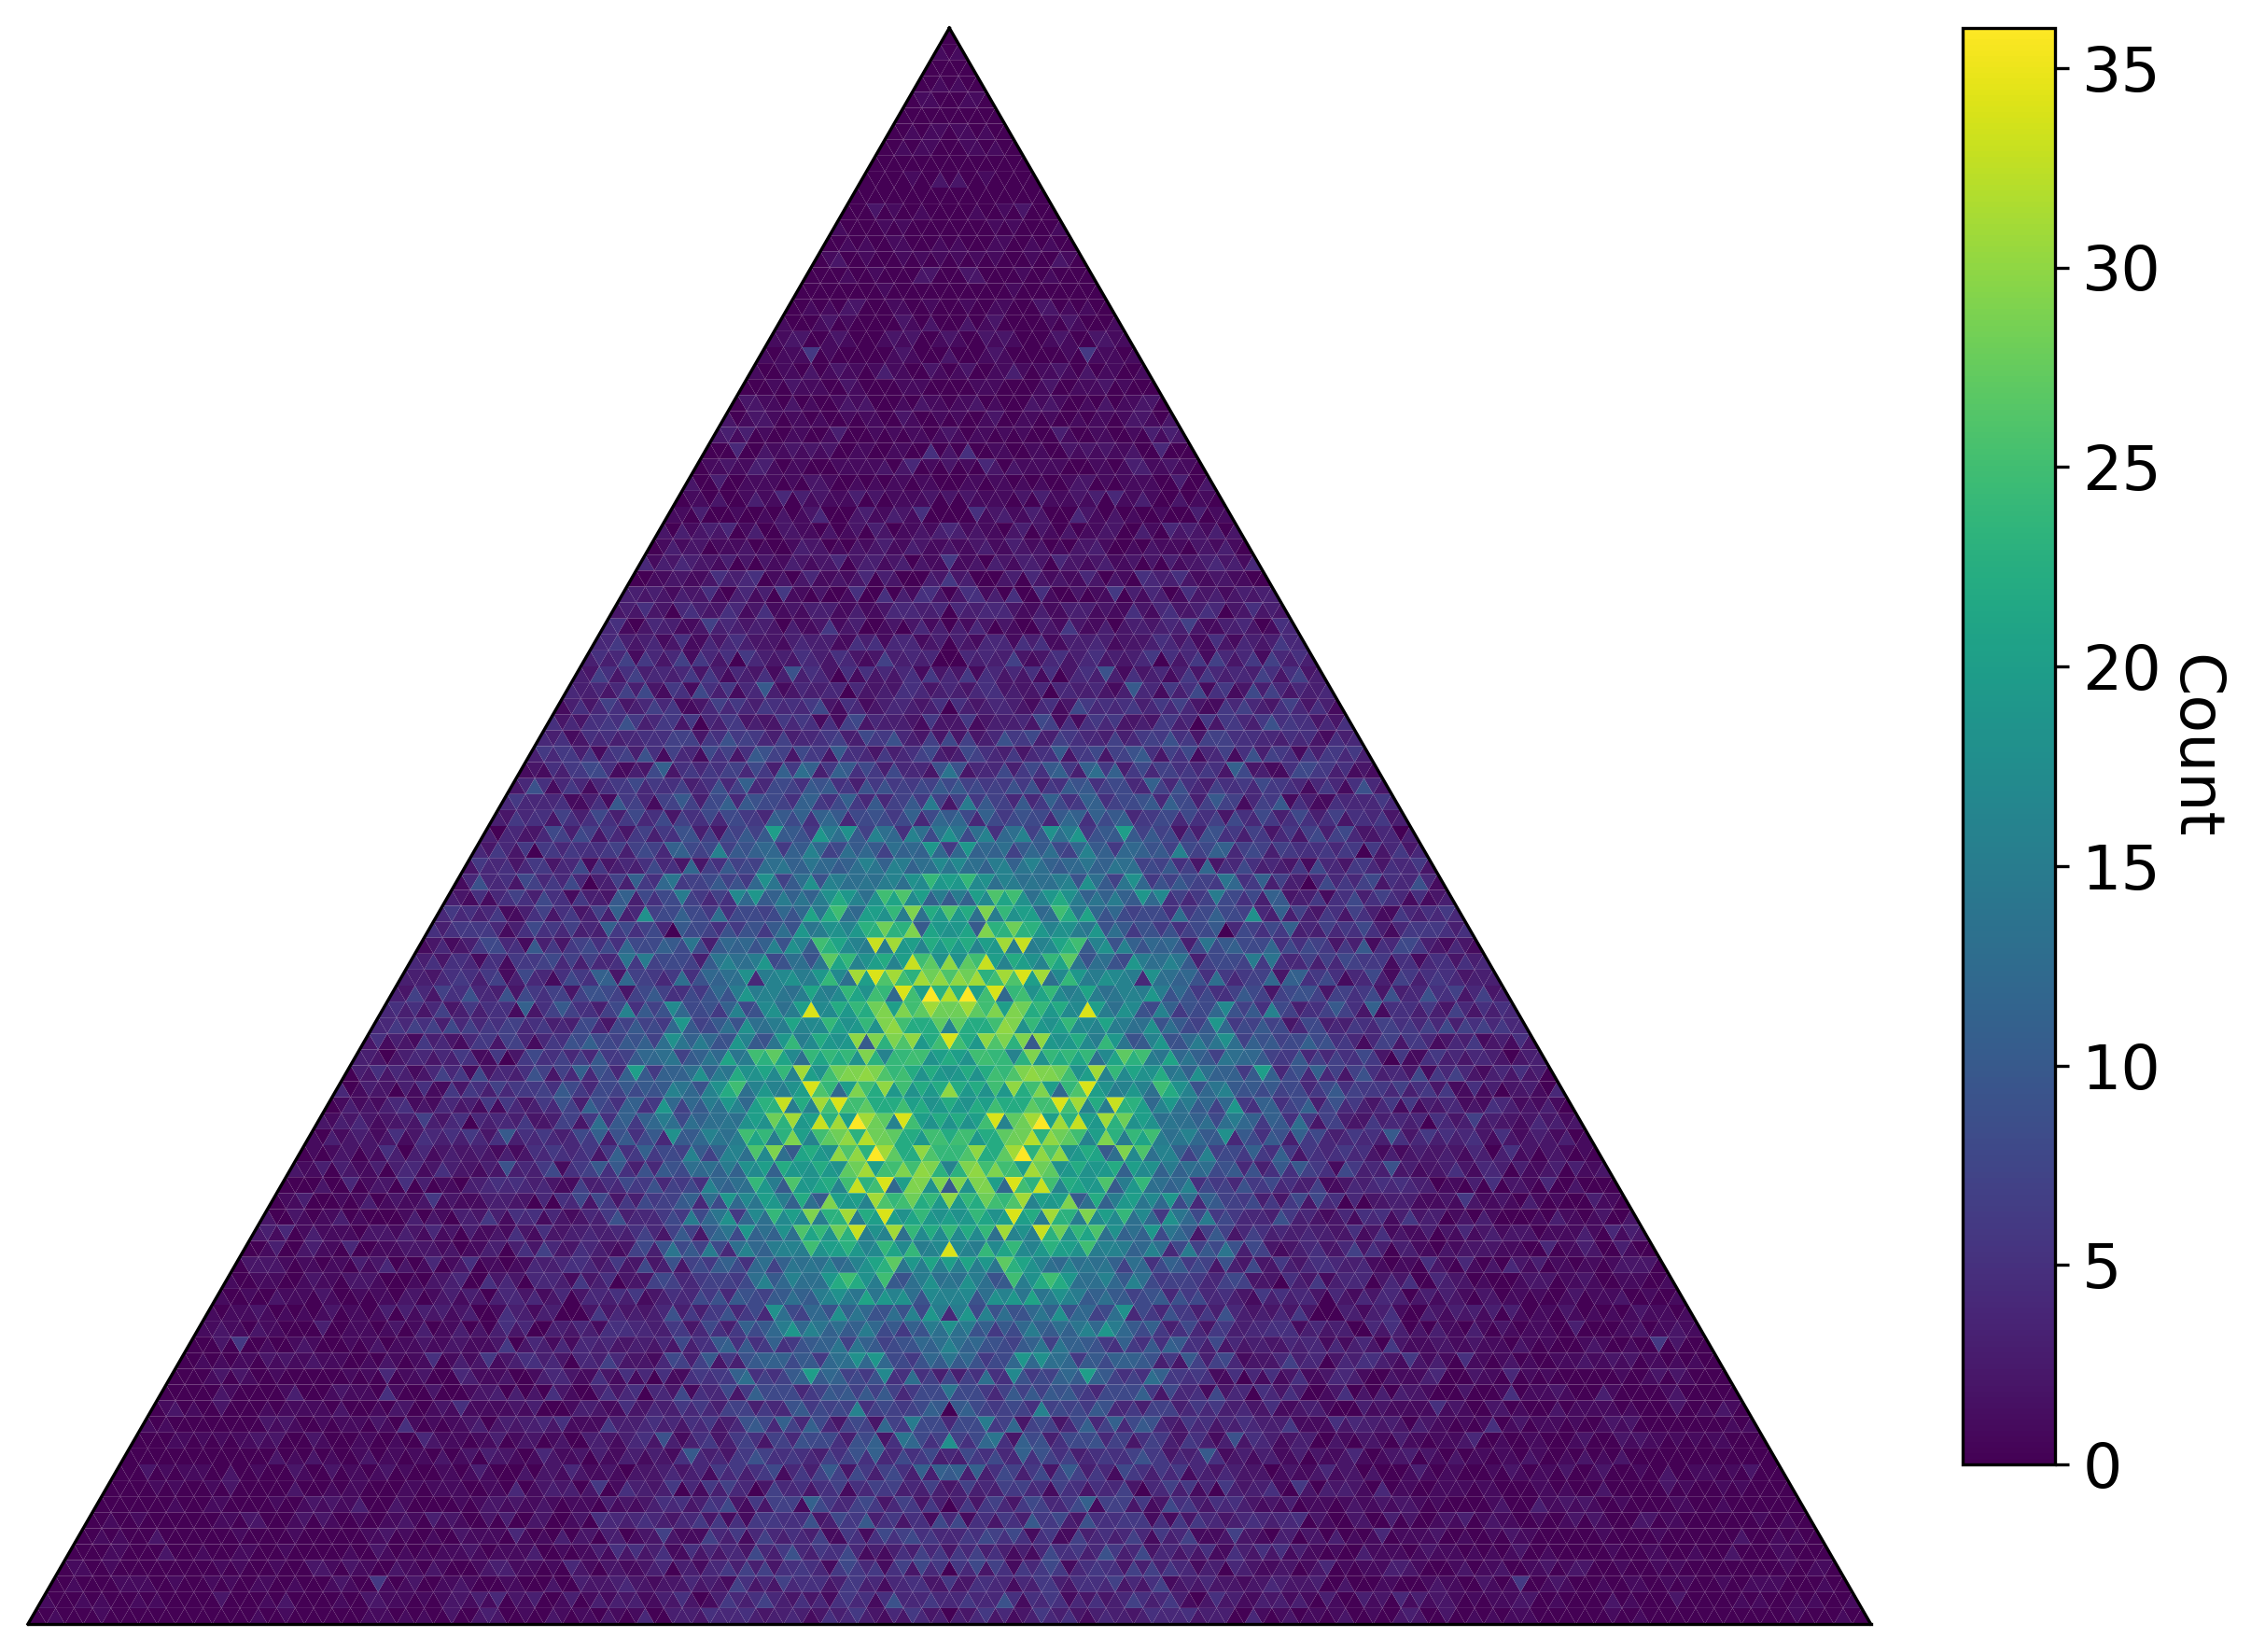

In [8]:
#draw single triangle (electrons with the same direction)

#creating a figure
#increase "dpi" to improve detail quality
fig = plt.figure(figsize=(12,6), dpi=300)
fig.subplots_adjust(
    left=0.1,
    right=0.9,
    bottom=0.1,
    top=0.9,
    wspace=0.5,
    hspace=0.5,
)

rotation = 0
down = 0

#the number of triangles into which the side of the triangle will be divided
grid = 100

ax = fig.add_subplot(1, 1, 1, projection='ternary', rotation=rotation)
#ax.set_title('all electrons one direction')

#Printing the data (ps[0], ps[1], ps[2])
#pc = ax.hexbin(main[0], main[1], main[2], gridsize = grid, edgecolors=None)
pc = ax.tribin(main[0], main[1], main[2], gridsize = grid, edgecolors=None)
cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9])
colorbar = fig.colorbar(pc, cax=cax)
colorbar.set_label("Count", rotation=270, va="baseline",fontsize=16)
colorbar.ax.tick_params(labelsize=16)
#disable ticks on axis
#comment 3 lines below to restore default settings
ax.taxis.set_ticks([])
ax.raxis.set_ticks([])
ax.laxis.set_ticks([])
#ax.set_tlabel('+')
#ax.set_llabel('+')
#ax.set_rlabel('+')
#ax.taxis.set_label_rotation_mode('horizontal')
#ax.laxis.set_label_rotation_mode('horizontal')
#ax.raxis.set_label_rotation_mode('horizontal')

plt.tight_layout()
plt.savefig('same direction only '+file[-9:-4]+'.png')
plt.show()